In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# !pip install wordcloud
from wordcloud import WordCloud, STOPWORDS

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("muted")
plt.rcParams['figure.figsize'] = (10, 6)

### 1. Read & Concat data

In [7]:
df_train = pd.read_csv('dataset/augmented_dataset/ielts_train_aug_df.csv')
df_test = pd.read_csv('dataset/augmented_dataset/ielts_test_locked_df.csv')
df_evals = pd.read_csv('dataset/augmented_dataset/ielts_evals_aug_df.csv')

df_train['split'] = 'train'
df_test['split'] = 'test'
df_evals['split'] = 'evals'

df = pd.concat([df_train, df_test, df_evals], ignore_index=True)

In [8]:
display(df.head())

,prompt,essay,evaluation,essay_len,TR,CC,LR,GRA,n_found,parse_quality,overall_raw,band,prompt_relevance,lexical_diversity,readability_score,target_text,source,split
0,Some people think that instead of preventing c...,"In recent decades, global warming has been rec...",Task Achievement: 6.0\r\nThe essay addresses t...,281,6.0,6.0,5.5,6.0,4,good,5.875,6.0,0.718834,0.607018,34.724422,Analysis: This essay has a lexical diversity o...,hf,train
1,"In some countries, more and more people are be...",It is often argued that the population of huma...,Task Achievement:\r\n- The candidate has adequ...,275,7.0,7.0,7.0,7.0,4,good,7.000,7.0,0.713550,0.512727,61.694028,Analysis: This essay has a lexical diversity o...,hf,train
2,In some countries people encourage teenagers t...,"Nowadays, more teenagers like to find a job. I...",Task Achievement:\r\n- The candidate has effec...,339,7.0,6.0,6.0,6.0,4,good,6.250,6.5,0.608461,0.513043,47.341609,Analysis: This essay has a lexical diversity o...,hf,train
3,It is important for all towns and cities to ha...,Some people argue that public spaces such as p...,Task Achievement:\r\n- The candidate has effec...,294,7.0,7.0,7.0,7.0,4,good,7.000,7.0,0.630358,0.616949,48.335395,Analysis: This essay has a lexical diversity o...,hf,train
4,Some people believe that the rage of technolog...,Technology is deeply relative to the living of...,Task Achievement: 5.5\r\n- The candidate has e...,296,5.5,6.0,6.0,6.0,4,good,5.875,6.0,0.729622,0.533557,40.290589,Analysis: This essay has a lexical diversity o...,hf,train


### 2. Data overview

In [9]:
print("--- THÔNG TIN CHUNG VỀ DATAFRAME ---")
df.info()

print("\n--- THỐNG KÊ MÔ TẢ CÁC BIẾN SỐ (NUMERICAL) ---")
display(df.describe().T)

print("\n--- KIỂM TRA DỮ LIỆU KHUYẾT THIẾU (MISSING VALUES) ---")
missing_data = df.isnull().sum()
display(missing_data[missing_data > 0])

--- THÔNG TIN CHUNG VỀ DATAFRAME ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9320 entries, 0 to 9319
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   prompt             9320 non-null   object 
 1   essay              9320 non-null   object 
 2   evaluation         9320 non-null   object 
 3   essay_len          9320 non-null   int64  
 4   TR                 9320 non-null   float64
 5   CC                 9320 non-null   float64
 6   LR                 9320 non-null   float64
 7   GRA                9320 non-null   float64
 8   n_found            9320 non-null   int64  
 9   parse_quality      9320 non-null   object 
 10  overall_raw        9320 non-null   float64
 11  band               9320 non-null   float64
 12  prompt_relevance   8016 non-null   float64
 13  lexical_diversity  8016 non-null   float64
 14  readability_score  8016 non-null   float64
 15  target_text        9320 non-null   

,count,mean,std,min,25%,50%,75%,max
essay_len,9320.0,298.127468,51.485105,98.000000,265.000000,291.000000,323.000000,1557.000000
TR,9320.0,6.130311,1.514550,0.000000,5.500000,6.500000,7.000000,9.000000
CC,9320.0,5.950858,1.671517,0.000000,5.000000,6.000000,7.000000,9.000000
LR,9320.0,5.714968,1.542354,0.000000,5.000000,6.000000,7.000000,9.000000
GRA,9320.0,5.665075,1.586822,0.000000,5.000000,6.000000,6.500000,9.000000
n_found,9320.0,4.000000,0.000000,4.000000,4.000000,4.000000,4.000000,4.000000
overall_raw,9320.0,5.869286,1.559279,0.000000,5.125000,6.125000,6.875000,9.000000
band,9320.0,5.937285,1.558671,0.000000,5.000000,6.000000,7.000000,9.000000
prompt_relevance,8016.0,0.657284,0.116526,-0.155265,0.609706,0.672572,0.729622,0.905569
lexical_diversity,8016.0,0.547766,0.053385,0.038328,0.514451,0.549550,0.583099,0.727273



--- KIỂM TRA DỮ LIỆU KHUYẾT THIẾU (MISSING VALUES) ---


prompt_relevance     1304
lexical_diversity    1304
readability_score    1304
dtype: int64

### 3. Overall Band Score

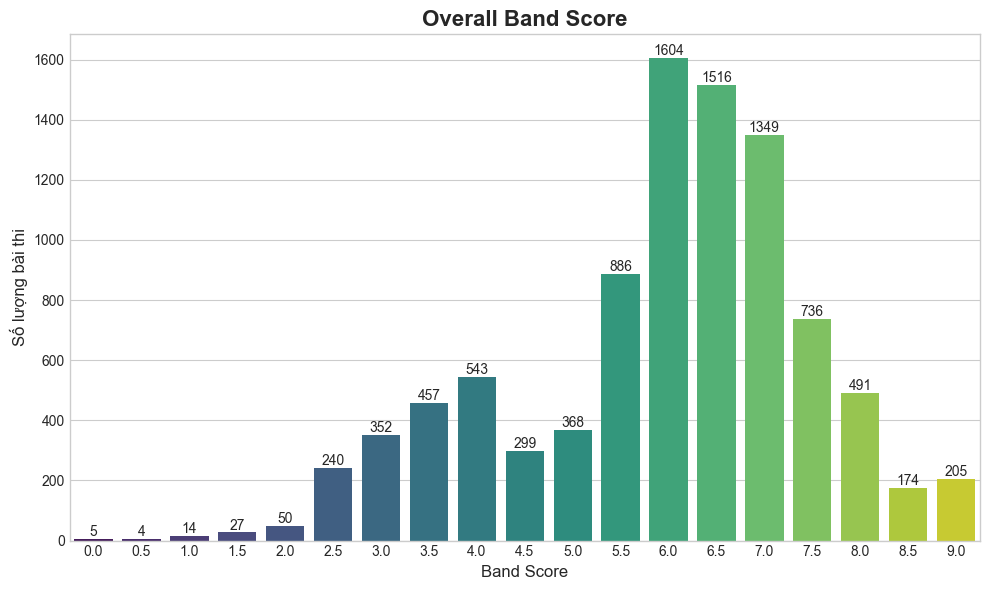

In [19]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='band', palette='viridis')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.title('Overall Band Score', fontsize=16, fontweight='bold')
plt.xlabel('Band Score', fontsize=12)
plt.ylabel('Số lượng bài thi', fontsize=12)
plt.tight_layout()
plt.show()

### 4. Essay Length

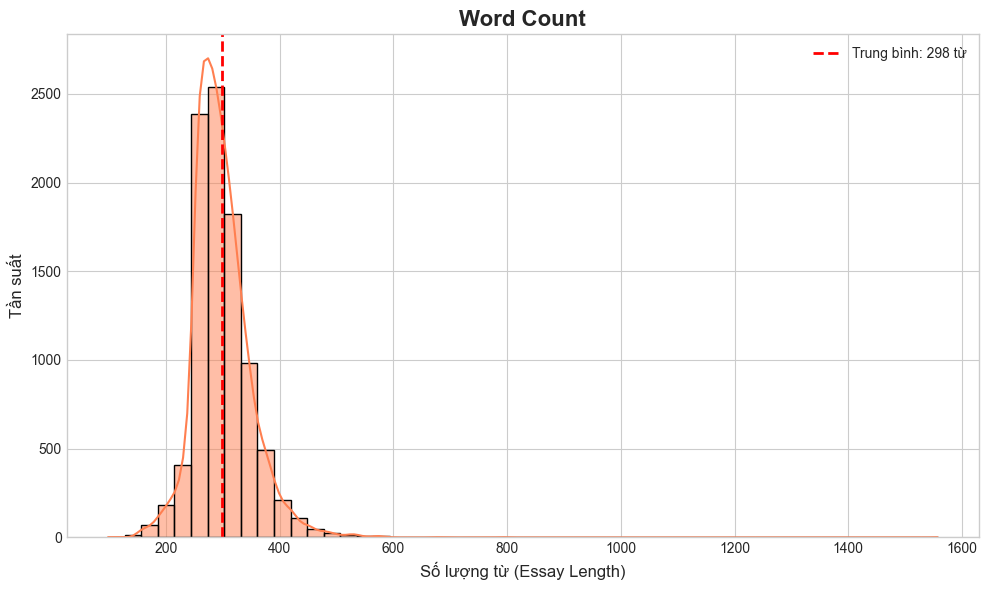

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='essay_len', bins=50, kde=True, color='coral')

mean_len = df['essay_len'].mean()
plt.axvline(mean_len, color='red', linestyle='dashed', linewidth=2, label=f'Trung bình: {mean_len:.0f} từ')

plt.title('Word Count', fontsize=16, fontweight='bold')
plt.xlabel('Số lượng từ (Essay Length)', fontsize=12)
plt.ylabel('Tần suất', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

### 5. Mối liên hệ Band Score & Essay Length

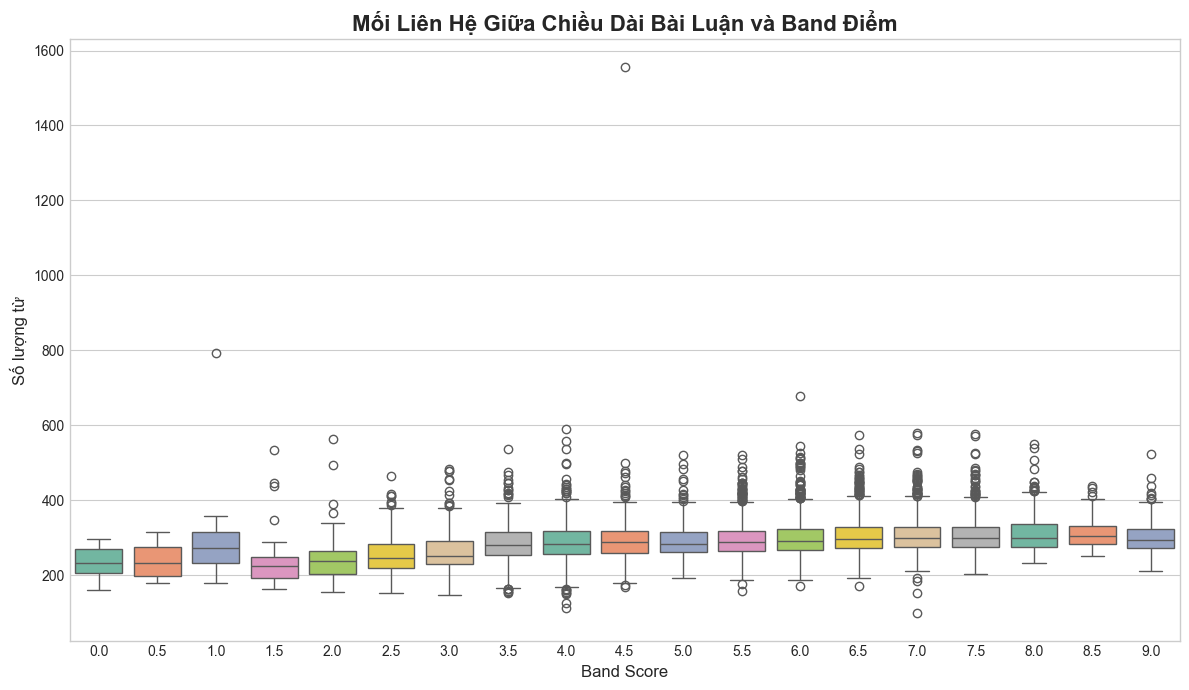

In [12]:
plt.figure(figsize=(12, 7))
sns.boxplot(data=df, x='band', y='essay_len', palette='Set2')

plt.title('Mối Liên Hệ Giữa Chiều Dài Bài Luận và Band Điểm', fontsize=16, fontweight='bold')
plt.xlabel('Band Score', fontsize=12)
plt.ylabel('Số lượng từ', fontsize=12)
plt.tight_layout()
plt.show()

### 6. Correlation Matrix

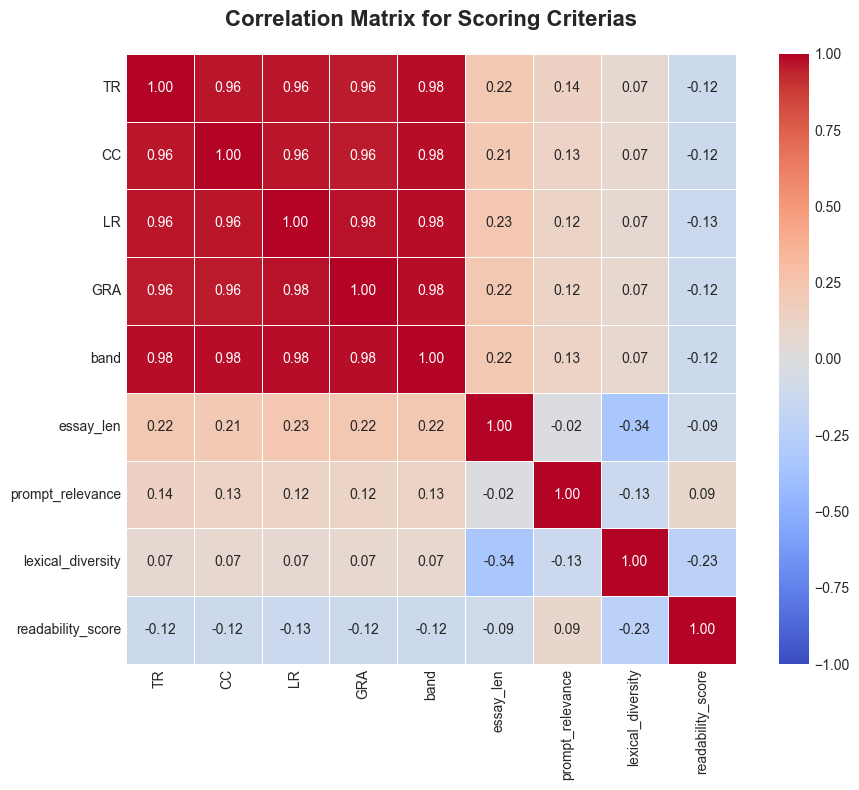

In [17]:
numeric_cols = ['TR', 'CC', 'LR', 'GRA', 'band', 'essay_len', 
                'prompt_relevance', 'lexical_diversity', 'readability_score']

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))

ax.grid(False)

sns.heatmap(corr_matrix, 
            annot=True, fmt=".2f", cmap='coolwarm', 
            vmin=-1, vmax=1, square=True, linewidths=.5,
            ax=ax)

plt.title('Correlation Matrix for Scoring Criterias', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### 7. WordCloud

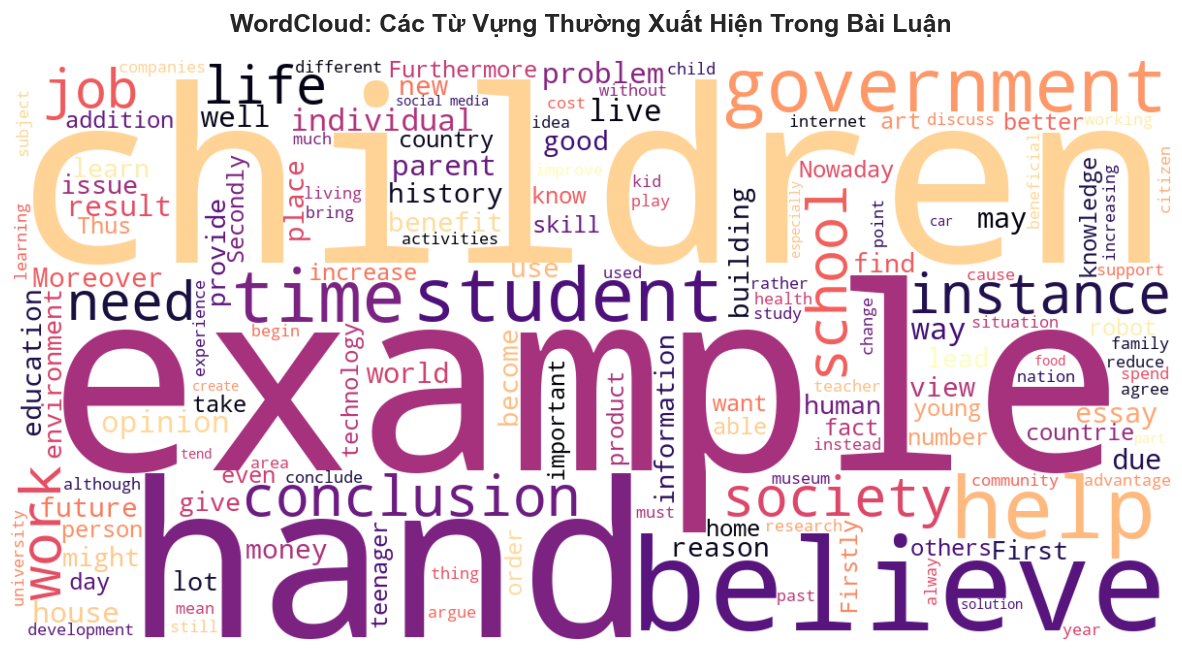

In [14]:
text_data = " ".join(essay for essay in df['essay'].dropna())

stopwords = set(STOPWORDS)
stopwords.update(["will", "people", "one", "many", "think", "make", "also"]) 

wordcloud = WordCloud(width=1200, height=600, 
                      background_color='white', 
                      stopwords=stopwords,
                      colormap='magma', 
                      max_words=150).generate(text_data)

plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off') # Tắt trục tọa độ
plt.title('WordCloud: Các Từ Vựng Thường Xuất Hiện Trong Bài Luận', fontsize=18, fontweight='bold', pad=20)
plt.show()